# Backward Repetition CRP

> Compute and visualize backward repetition lag-CRP for repeated items.

The backward repetition CRP analysis tabulates lag transitions TO repeated items (as opposed to FROM repeated items in the standard repetition CRP). This reveals how transitions converge toward repeated items from their neighbors during free recall.

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty string to skip saving) |
| `ylim` | Y-axis limits as tuple, or `None` for auto |
| `mixed_trial_query` | Query string selecting mixed (repeated-item) trials |
| `control_trial_query` | Query string selecting pure (control) trials |
| `control_shuffles` | Number of shuffled control blocks per subject |
| `min_lag` | Minimum spacing between repeated occurrences |
| `max_lag` | Maximum lag to display |
| `size` | Maximum presentations per item |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.backrepcrp import (
    plot_back_rep_crp,
    repcrp,
    tabulate_trial,
    subject_back_rep_crp,
    test_back_rep_crp_vs_control,
    test_first_second_bias,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.repetition import make_control_dataset

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
mixed_trial_query = 'data["list_type"] == 4'
control_trial_query = 'data["list_type"] == 1'
control_shuffles = 10
min_lag = 4
max_lag = 5
size = 2

In [4]:
#| code-summary: Load data and build control dataset
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, mixed_trial_query)
control_dataset = make_control_dataset(
    data, mixed_trial_query, control_trial_query, control_shuffles
)
control_mask = generate_trial_mask(control_dataset, mixed_trial_query)

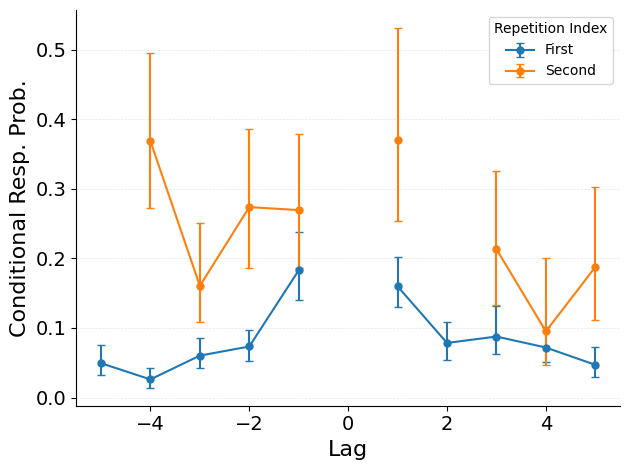

In [5]:
#| code-summary: Plot backward repetition Lag-CRP (observed)
#| label: fig-backrepcrp
#| fig-cap: "Backward repetition Lag-CRP for each presentation index of repeated items."
plot_back_rep_crp(
    data,
    trial_mask,
    max_lag=max_lag,
    min_lag=min_lag,
    size=size,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str, suffix="mixed")

---

## Reference

In [6]:
#| echo: false
show_doc(plot_back_rep_crp)

---

### plot_back_rep_crp

>      plot_back_rep_crp (datasets:Union[Sequence[jaxcmr.typing.RecallDataset],j
>                         axcmr.typing.RecallDataset], trial_masks:Union[Sequenc
>                         e[jaxtyping.Bool[Array,'trial_count']],jaxtyping.Bool[
>                         Array,'trial_count']], max_lag:int=5, min_lag:int=4,
>                         size:int=2, repetition_index:Optional[int]=None,
>                         color_cycle:Optional[list[str]]=None,
>                         labels:Optional[Sequence[str]]=None,
>                         contrast_name:Optional[str]=None,
>                         axis:Optional[matplotlib.axes._axes.Axes]=None,
>                         confidence_level:float=0.95)

*Plot backward repetition lag-CRP with CIs.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | Datasets containing trial data to plot. |
| trial_masks | Union |  | Masks to filter trials in datasets. |
| max_lag | int | 5 | Maximum lag to display. |
| min_lag | int | 4 | Minimum spacing between repeated occurrences. |
| size | int | 2 | Maximum presentations per item. |
| repetition_index | Optional | None | Plot only this repetition index. |
| color_cycle | Optional | None | Colors for each curve. |
| labels | Optional | None | Legend labels for repetition-index lines. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Axes to plot on. |
| confidence_level | float | 0.95 | Confidence level for error bounds. |
| **Returns** | **Axes** |  | **Axes with the backward repetition CRP plot.** |

In [7]:
#| echo: false
show_doc(repcrp)

---

### repcrp

>      repcrp (dataset:jaxcmr.typing.RecallDataset, min_lag:int=4, size:int=2)

*Backward repetition lag-CRP per presentation index.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Dataset with ``recalls`` and ``pres_itemnos``. |
| min_lag | int | 4 | Minimum separation between repeated presentations. |
| size | int | 2 | Maximum presentations per item. |
| **Returns** | **Float[Array, 'lags']** |  | **CRP of shape ``(size, 2*L-1)`` per repetition<br>index.** |

In [8]:
#| echo: false
show_doc(tabulate_trial)

---

### tabulate_trial

>      tabulate_trial (trial:jaxtyping.Integer[Array,'recall_events'],
>                      presentation:jaxtyping.Integer[Array,'study_events'],
>                      min_lag=4, size:int=2)

*Tabulate observed and available lags for a trial.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| trial | Integer[Array, 'recall_events'] |  | Recall events for a single trial. |
| presentation | Integer[Array, 'study_events'] |  | Study events for the trial. |
| min_lag | int | 4 | Minimum spacing between item repetitions. |
| size | int | 2 | Maximum presentations per item. |
| **Returns** | **tuple** |  | **Actual and available lag tabulations.** |

In [9]:
#| echo: false
show_doc(subject_back_rep_crp)

---

### subject_back_rep_crp

>      subject_back_rep_crp (dataset:jaxcmr.typing.RecallDataset,
>                            trial_mask:jaxtyping.Bool[Array,'trial_count'],
>                            min_lag:int=4, max_lag:int=5, size:int=2)

*Compute subject-level backward repetition CRP.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Recall dataset. |
| trial_mask | Bool[Array, 'trial_count'] |  | Boolean mask selecting trials to include. |
| min_lag | int | 4 | Minimum spacing between item repetitions. |
| max_lag | int | 5 | Maximum lag to include in output. |
| size | int | 2 | Maximum presentations per item. |
| **Returns** | **ndarray** |  |  |

In [10]:
#| echo: false
show_doc(test_back_rep_crp_vs_control)

---

### test_back_rep_crp_vs_control

>      test_back_rep_crp_vs_control (observed_crp:numpy.ndarray,
>                                    control_crp:numpy.ndarray, max_lag:int=5)

*Test observed vs control backward CRP per index.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| observed_crp | ndarray |  | Subject-level CRP from observed data.<br>Shape ``(n_subjects, size, 2*max_lag+1)``. |
| control_crp | ndarray |  | Subject-level CRP from control data.<br>Shape ``(n_subjects, size, 2*max_lag+1)``. |
| max_lag | int | 5 | Maximum lag used for labeling. |
| **Returns** | **dict** |  |  |

In [11]:
#| echo: false
show_doc(test_first_second_bias)

---

### test_first_second_bias

>      test_first_second_bias (observed_crp:numpy.ndarray,
>                              control_crp:numpy.ndarray, max_lag:int=5)

*Test whether first-presentation bias differs.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| observed_crp | ndarray |  | Subject-level CRP from observed data.<br>Shape ``(n_subjects, size, 2*max_lag+1)``. |
| control_crp | ndarray |  | Subject-level CRP from control data.<br>Shape ``(n_subjects, size, 2*max_lag+1)``. |
| max_lag | int | 5 | Maximum lag used for labeling. |
| **Returns** | **BackRepCRPTestResult** |  |  |